# Face Generation

In this project, you'll define and train a DCGAN on a dataset of faces. Your goal is to get a generator network to generate *new* images of faces that look as realistic as possible!

The project will be broken down into a series of tasks from **loading in data to defining and training adversarial networks**. At the end of the notebook, you'll be able to visualize the results of your trained Generator to see how it performs; your generated samples should look like fairly realistic faces with small amounts of noise.

### Get the Data

You'll be using the [CelebFaces Attributes Dataset (CelebA)](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) to train your adversarial networks.

This dataset is more complex than the number datasets (like MNIST or SVHN) you've been working with, and so, you should prepare to define deeper networks and train them for a longer time to get good results. It is suggested that you utilize a GPU for training.

### Pre-processed Data

Since the project's main focus is on building the GANs, we've done *some* of the pre-processing for you. Each of the CelebA images has been cropped to remove parts of the image that don't include a face, then resized down to 64x64x3 NumPy images. Some sample data is show below.

![](./assets/processed_face_data.png)

> If you are working locally, you can download this data [by clicking here](https://s3.amazonaws.com/video.udacity-data.com/topher/2018/November/5be7eb6f_processed-celeba-small/processed-celeba-small.zip)

This is a zip file that you'll need to extract in the home directory of this notebook for further loading and processing. After extracting the data, you should be left with a directory of data `processed_celeba_small/`

In [1]:
# can comment out after executing
#!unzip processed_celeba_small.zip

In [2]:
data_dir = 'processed_celeba_small/'

"""
DON'T MODIFY ANYTHING IN THIS CELL
"""
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np
import problem_unittests as tests
#import helper

%matplotlib inline

## Visualize the CelebA Data

The [CelebA](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) dataset contains over 200,000 celebrity images with annotations. Since you're going to be generating faces, you won't need the annotations, you'll only need the images. Note that these are color images with [3 color channels (RGB)](https://en.wikipedia.org/wiki/Channel_(digital_image)#RGB_Images) each.

### Pre-process and Load the Data

Since the project's main focus is on building the GANs, we've done *some* of the pre-processing for you. Each of the CelebA images has been cropped to remove parts of the image that don't include a face, then resized down to 64x64x3 NumPy images. This *pre-processed* dataset is a smaller subset of the very large CelebA data.

> There are a few other steps that you'll need to **transform** this data and create a **DataLoader**.

#### Exercise: Complete the following `get_dataloader` function, such that it satisfies these requirements:

* Your images should be square, Tensor images of size `image_size x image_size` in the x and y dimension.
* Your function should return a DataLoader that shuffles and batches these Tensor images.

#### ImageFolder

To create a dataset given a directory of images, it's recommended that you use PyTorch's [ImageFolder](https://pytorch.org/docs/stable/torchvision/datasets.html#imagefolder) wrapper, with a root directory `processed_celeba_small/` and data transformation passed in.

In [3]:
# necessary imports
import os

import torch
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

# number of subprocesses to use for data loading
num_threads = 24
# Device types: cpu, xpu, cuda
device_type = "xpu"

In [4]:
def get_dataloader(batch_size, image_size, data_dir='processed_celeba_small/'):
    """
    Batch the neural network data using DataLoader
    :param batch_size: The size of each batch; the number of images in a batch
    :param img_size: The square size of the image data (x, y)
    :param data_dir: Directory where image data is located
    :return: DataLoader with batched data
    """
    
    # TODO: Implement function and return a dataloader
    # resize and normalize the images
    transform = transforms.Compose([transforms.Resize(image_size), # resize to 32x32
                                    transforms.ToTensor()])
    
    celeb_path = os.path.join('./' + data_dir, 'celeba')
    celeb_dataset = datasets.ImageFolder(celeb_path, transform)
    
    celeb_loader = DataLoader(dataset=celeb_dataset, batch_size=batch_size, \
                              shuffle=True, num_workers=num_threads)
    
    return celeb_loader

## Create a DataLoader

#### Exercise: Create a DataLoader `celeba_train_loader` with appropriate hyperparameters.

Call the above function and create a dataloader to view images. 
* You can decide on any reasonable `batch_size` parameter
* Your `image_size` **must be** `32`. Resizing the data to a smaller size will make for faster training, while still creating convincing images of faces!

In [5]:
# Define function hyperparameters
batch_size = 128
img_size = 32

"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
# Call your function and get a dataloader
celeba_train_loader = get_dataloader(batch_size, img_size)


Next, you can view some images! You should seen square images of somewhat-centered faces.

Note: You'll need to convert the Tensor images into a NumPy type and transpose the dimensions to correctly display an image, suggested `imshow` code is below, but it may not be perfect.

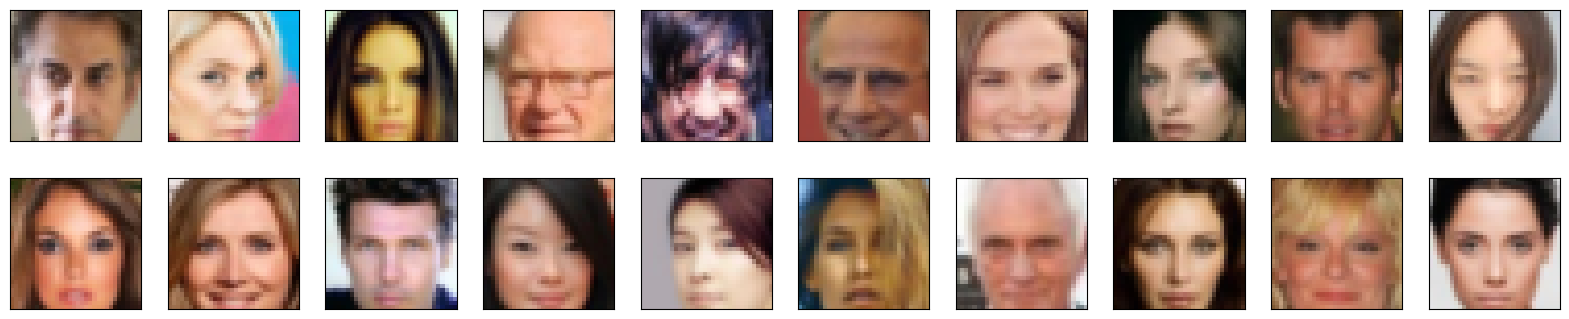

In [6]:
# helper display function
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
# obtain one batch of training images
dataiter = iter(celeba_train_loader)
images, _ = next(dataiter) # _ for no labels

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(20, 4))
plot_size=20
for idx in np.arange(plot_size):
    ax = fig.add_subplot(2, int(plot_size/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])

#### Exercise: Pre-process your image data and scale it to a pixel range of -1 to 1

You need to do a bit of pre-processing; you know that the output of a `tanh` activated generator will contain pixel values in a range from -1 to 1, and so, we need to rescale our training images to a range of -1 to 1. (Right now, they are in a range from 0-1.)

In [7]:
# TODO: Complete the scale function
def scale(x, feature_range=(-1, 1)):
    ''' Scale takes in an image x and returns that image, scaled
       with a feature_range of pixel values from -1 to 1. 
       This function assumes that the input x is already scaled from 0-1.'''
    # assume x is scaled to (0, 1)
    # scale to feature_range and return scaled x
    min_value, max_value = feature_range
    scaled_x = x * (max_value - min_value) + min_value
    return scaled_x

In [8]:
"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
# check scaled range
# should be close to -1 to 1
img = images[0]
scaled_img = scale(img)

print('Min: ', scaled_img.min())
print('Max: ', scaled_img.max())

Min:  tensor(-0.8980)
Max:  tensor(0.9922)


In [9]:
print('Unscaled')
print('Min: ', img.min())
print('Max: ', img.max())

Unscaled
Min:  tensor(0.0510)
Max:  tensor(0.9961)


---
# Define the Model

A GAN is comprised of two adversarial networks, a discriminator and a generator.

## Discriminator

Your first task will be to define the discriminator. This is a convolutional classifier like you've built before, only without any maxpooling layers. To deal with this complex data, it's suggested you use a deep network with **normalization**. You are also allowed to create any helper functions that may be useful.

#### Exercise: Complete the Discriminator class
* The inputs to the discriminator are 32x32x3 tensor images
* The output should be a single value that will indicate whether a given image is real or fake


In [10]:
import torch.nn as nn
import torch.nn.functional as F

In [11]:
def convBatchNorm2d(in_channels, out_channels, 
                    kernel_size, stride=2, padding=1, batch_norm=True):
    layers = []
    layers.append(nn.Conv2d(in_channels, out_channels, 
                            kernel_size, stride, padding, bias=False))
    if batch_norm:
        layers.append(nn.BatchNorm2d(num_features=out_channels))

    return nn.Sequential(*layers)

In [12]:
class Discriminator(nn.Module):

    def __init__(self, conv_dim):
        """
        Initialize the Discriminator Module
        :param conv_dim: The depth of the first convolutional layer
        """
        super(Discriminator, self).__init__()

        # complete init function
        # 3 x 32 x 32
        self.conv_layer1 = convBatchNorm2d(in_channels=3, out_channels=conv_dim, 
                                           kernel_size=4, stride=2, padding=1, 
                                           batch_norm=False)
        # conv_dim x 16 x 16
        self.conv_layer2 = convBatchNorm2d(in_channels=conv_dim, out_channels=conv_dim*2, 
                                           kernel_size=4, stride=2, padding=1, 
                                           batch_norm=True)
        # conv_dim*2 x 8 x 8
        self.conv_layer3 = convBatchNorm2d(in_channels=conv_dim*2, out_channels=conv_dim*4, 
                                           kernel_size=4, stride=2, padding=1, 
                                           batch_norm=True)
        # conv_dim*4 x 4 x 4
        self.flatten_dimension = conv_dim*4 * 4 * 4
        
        self.leaky_relu_activation = nn.LeakyReLU(negative_slope=0.2)
        self.fc_layer = nn.Linear(self.flatten_dimension, 1)
        

    def forward(self, x):
        """
        Forward propagation of the neural network
        :param x: The input to the neural network     
        :return: Discriminator logits; the output of the neural network
        """
        # define feedforward behavior
        x = self.conv_layer1(x)
        x = self.leaky_relu_activation(x)
        x = self.conv_layer2(x)
        x = self.leaky_relu_activation(x)
        x = self.conv_layer3(x)
        x = self.leaky_relu_activation(x)
        x = x.view(-1, self.flatten_dimension)
        x = self.fc_layer(x)
        
        return x


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
tests.test_discriminator(Discriminator)

Tests Passed


## Generator

The generator should upsample an input and generate a *new* image of the same size as our training data `32x32x3`. This should be mostly transpose convolutional layers with normalization applied to the outputs.

#### Exercise: Complete the Generator class
* The inputs to the generator are vectors of some length `z_size`
* The output should be a image of shape `32x32x3`

In [13]:
def convTransposeBatchNorm2d(in_channels, out_channels, 
                             kernel_size, stride=2, padding=1, batch_norm=True):
    layers = []
    layers.append(nn.ConvTranspose2d(in_channels, out_channels, 
                                     kernel_size, stride, padding, bias=False))
    if batch_norm:
        layers.append(nn.BatchNorm2d(out_channels))
    
    return nn.Sequential(*layers)

In [14]:
class Generator(nn.Module):
    
    def __init__(self, z_size, conv_dim):
        """
        Initialize the Generator Module
        :param z_size: The length of the input latent vector, z
        :param conv_dim: The depth of the inputs to the *last* transpose convolutional layer
        """
        super(Generator, self).__init__()

        # complete init function
        self.conv_dim = conv_dim
        self.fc_layer = nn.Linear(z_size, self.conv_dim*4 * 4 * 4)
        
        # conv_dim*4 x 4 x 4
        self.convt_layer1 = convTransposeBatchNorm2d(
                                in_channels=conv_dim*4, out_channels=conv_dim*2, 
                                kernel_size=4, stride=2, padding=1, batch_norm=True)
        # conv_dim*2 x 8 x 8
        self.convt_layer2 = convTransposeBatchNorm2d(
                                in_channels=conv_dim*2, out_channels=conv_dim, 
                                kernel_size=4, stride=2, padding=1, batch_norm=True)
        # conv_dim x 16 x 16
        self.convt_layer3 = convTransposeBatchNorm2d(
                                in_channels=conv_dim, out_channels=3, 
                                kernel_size=4, stride=2, padding=1, batch_norm=False)
        # 3 x 32 x 32
        
        self.relu_activation = nn.ReLU()
        self.tanh_activation = nn.Tanh()
        

    def forward(self, x):
        """
        Forward propagation of the neural network
        :param x: The input to the neural network     
        :return: A 32x32x3 Tensor image as output
        """
        # define feedforward behavior
        x = self.fc_layer(x)
        x = x.view(-1, self.conv_dim*4, 4, 4)
        x = self.convt_layer1(x)
        x = self.relu_activation(x)
        x = self.convt_layer2(x)
        x = self.relu_activation(x)
        x = self.convt_layer3(x)
        x = self.tanh_activation(x)
        
        return x

"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
tests.test_generator(Generator)

Tests Passed


## Initialize the weights of your networks

To help your models converge, you should initialize the weights of the convolutional and linear layers in your model. From reading the [original DCGAN paper](https://arxiv.org/pdf/1511.06434.pdf), they say:
> All weights were initialized from a zero-centered Normal distribution with standard deviation 0.02.

So, your next task will be to define a weight initialization function that does just this!

You can refer back to the lesson on weight initialization or even consult existing model code, such as that from [the `networks.py` file in CycleGAN Github repository](https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix/blob/master/models/networks.py) to help you complete this function.

#### Exercise: Complete the weight initialization function

* This should initialize only **convolutional** and **linear** layers
* Initialize the weights to a normal distribution, centered around 0, with a standard deviation of 0.02.
* The bias terms, if they exist, may be left alone or set to 0.

In [15]:
from torch.nn import init

def weights_init_normal(m):
    """
    Applies initial weights to certain layers in a model .
    The weights are taken from a normal distribution 
    with mean = 0, std dev = 0.02.
    :param m: A module or layer in a network    
    """
    # classname will be something like:
    # `Conv`, `BatchNorm2d`, `Linear`, etc.
    classname = m.__class__.__name__
    
    # TODO: Apply initial weights to convolutional and linear layers
    if hasattr(m, 'weight') and (classname.find('Conv') != -1 or classname.find('Linear') != -1):
        init.normal_(m.weight.data, mean=0.0, std=0.02)
        if hasattr(m, 'bias') and m.bias is not None:
            init.constant_(m.bias.data, 0.0)

## Build complete network

Define your models' hyperparameters and instantiate the discriminator and generator from the classes defined above. Make sure you've passed in the correct input arguments.

In [16]:
"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
def build_network(d_conv_dim, g_conv_dim, z_size):
    # define discriminator and generator
    D = Discriminator(d_conv_dim)
    G = Generator(z_size=z_size, conv_dim=g_conv_dim)

    # initialize model weights
    D.apply(weights_init_normal)
    G.apply(weights_init_normal)

    print(D)
    print()
    print(G)
    
    return D, G


#### Exercise: Define model hyperparameters

In [17]:
# Define model hyperparams
d_conv_dim = 128
g_conv_dim = 128
z_size = 100

"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
D, G = build_network(d_conv_dim, g_conv_dim, z_size)

Discriminator(
  (conv_layer1): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  )
  (conv_layer2): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_layer3): Sequential(
    (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (leaky_relu_activation): LeakyReLU(negative_slope=0.2)
  (fc_layer): Linear(in_features=8192, out_features=1, bias=True)
)

Generator(
  (fc_layer): Linear(in_features=100, out_features=8192, bias=True)
  (convt_layer1): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (convt_layer

### Training on GPU

Check if you can train on GPU. Here, we'll set `device` to `xpu` or `cuda`. Later, you'll be responsible for making sure that 
* Models,
* Model inputs, and
* Loss function arguments

Are moved to GPU, where appropriate.

In [18]:
"""
DON'T MODIFY ANYTHING IN THIS CELL
"""
import torch

# Use GPU when available
device = torch.device(device_type)
print(device)

xpu


---
## Discriminator and Generator Losses

Now we need to calculate the losses for both types of adversarial networks.

### Discriminator Losses

> * For the discriminator, the total loss is the sum of the losses for real and fake images, `d_loss = d_real_loss + d_fake_loss`. 
* Remember that we want the discriminator to output 1 for real images and 0 for fake images, so we need to set up the losses to reflect that.


### Generator Loss

The generator loss will look similar only with flipped labels. The generator's goal is to get the discriminator to *think* its generated images are *real*.

#### Exercise: Complete real and fake loss functions

**You may choose to use either cross entropy or a least squares error loss to complete the following `real_loss` and `fake_loss` functions.**

In [19]:
def real_loss(D_out):
    '''Calculates how close discriminator outputs are to being real.
       param, D_out: discriminator logits
       return: real loss'''
    batch_size = D_out.size(0)
    labels = torch.ones(batch_size) # real labels = 1
    # move labels to GPU if available     
    labels = labels.to(device)
    # binary cross entropy with logits loss
    criterion = nn.BCEWithLogitsLoss()
    # calculate loss
    loss = criterion(D_out.squeeze(), labels)
    return loss

def fake_loss(D_out):
    '''Calculates how close discriminator outputs are to being fake.
       param, D_out: discriminator logits
       return: fake loss'''
    batch_size = D_out.size(0)
    labels = torch.zeros(batch_size) # fake labels = 0
    labels = labels.to(device)
    criterion = nn.BCEWithLogitsLoss()
    # calculate loss
    loss = criterion(D_out.squeeze(), labels)
    return loss

## Optimizers

#### Exercise: Define optimizers for your Discriminator (D) and Generator (G)

Define optimizers for your models with appropriate hyperparameters.

In [20]:
import torch.optim as optim

lr = 0.0002
beta1 = 0.5
beta2 = 0.999
# Create optimizers for the discriminator D and generator G
d_optimizer = optim.Adam(D.parameters(), lr, [beta1, beta2])
g_optimizer = optim.Adam(G.parameters(), lr, [beta1, beta2])

---
## Training

Training will involve alternating between training the discriminator and the generator. You'll use your functions `real_loss` and `fake_loss` to help you calculate the discriminator losses.

* You should train the discriminator by alternating on real and fake images
* Then the generator, which tries to trick the discriminator and should have an opposing loss function


#### Saving Samples

You've been given some code to print out some loss statistics and save some generated "fake" samples.

#### Exercise: Complete the training function

Keep in mind that, if you've moved your models to GPU, you'll also have to move any model inputs to GPU.

In [21]:
import time

def train(D, G, n_epochs, print_every=50):
    '''Trains adversarial networks for some number of epochs
       param, D: the discriminator network
       param, G: the generator network
       param, n_epochs: number of epochs to train for
       param, print_every: when to print and record the models' losses
       return: D and G losses'''
    
    # move models to GPU when available
    D.to(device)
    G.to(device)

    # keep track of loss and generated, "fake" samples
    samples = []
    losses = []

    # Get some fixed data for sampling. These are images that are held
    # constant throughout training, and allow us to inspect the model's performance
    sample_size=16
    fixed_z = np.random.uniform(-1, 1, size=(sample_size, z_size))
    fixed_z = torch.from_numpy(fixed_z).float()
    # move z to GPU if available
    fixed_z = fixed_z.to(device)

    for epoch in range(n_epochs):
        # epoch training loop
        tic = time.time()
        # batch training loop
        for batch_i, (real_images, _) in enumerate(celeba_train_loader):

            batch_size = real_images.size(0)
            real_images = scale(real_images)

            # ===============================================
            #         YOUR CODE HERE: TRAIN THE NETWORKS
            # ===============================================
            d_optimizer.zero_grad()
            
            # 1. Train the discriminator on real and fake images
            # 1.a. Train with real images
            # Compute the discriminator losses on real images 
            real_images = real_images.to(device)
        
            D_real = D(real_images)
            d_real_loss = real_loss(D_real)
            
            # 1.b. Train with fake images
            # Generate fake images
            z = np.random.uniform(-1, 1, size=(batch_size, z_size))
            z = torch.from_numpy(z).float()
            # move x to GPU, if available
            z = z.to(device)
            fake_images = G(z)
            # Compute the discriminator losses on fake images            
            D_fake = D(fake_images)
            d_fake_loss = fake_loss(D_fake)
            # add up loss
            d_loss = d_real_loss + d_fake_loss
            # perform backprop
            d_loss.backward()
            d_optimizer.step()

            # 2. Train the generator with an adversarial loss
            g_optimizer.zero_grad()
            # Generate fake images
            z = np.random.uniform(-1, 1, size=(batch_size, z_size))
            z = torch.from_numpy(z).float()
            z = z.to(device)
            fake_images = G(z)
            # Compute the discriminator losses on fake images 
            # using flipped labels!
            D_fake = D(fake_images)
            # use real loss to flip labels
            # NOT RECOMMENDED: use proper flip labels instead
            g_loss = real_loss(D_fake) # use real loss to flip labels
            # perform backprop
            g_loss.backward()
            g_optimizer.step()
            
            
            # ===============================================
            #              END OF YOUR CODE
            # ===============================================

            # Print some loss stats
            if batch_i % print_every == 0:
                # append discriminator loss and generator loss
                losses.append((d_loss.item(), g_loss.item()))
                # print discriminator and generator loss
                print('Epoch [{:5d}/{:5d}] | d_loss: {:6.4f} | g_loss: {:6.4f}'.format(
                        epoch+1, n_epochs, d_loss.item(), g_loss.item()))

        toc = time.time()
        print("runtime: %6.2f seconds" % (toc-tic))
        ## AFTER EACH EPOCH##    
        # this code assumes your generator is named G, feel free to change the name
        # generate and save sample, fake images
        G.eval() # for generating samples
        samples_z = G(fixed_z)
        samples.append(samples_z)
        G.train() # back to training mode

    # Save training generator samples
    with open('train_samples.pkl', 'wb') as f:
        pkl.dump(samples, f)
    
    # finally return losses
    return losses

Set your number of training epochs and train your GAN!

In [22]:
# set number of epochs 
n_epochs = 30


"""
DON'T MODIFY ANYTHING IN THIS CELL
"""
# call training function
losses = train(D, G, n_epochs=n_epochs)

Epoch [    1/   30] | d_loss: 1.8524 | g_loss: 2.5197
Epoch [    1/   30] | d_loss: 0.1259 | g_loss: 0.2603
Epoch [    1/   30] | d_loss: 0.2954 | g_loss: 4.2678
Epoch [    1/   30] | d_loss: 0.9484 | g_loss: 3.8616
Epoch [    1/   30] | d_loss: 1.3900 | g_loss: 0.8297
Epoch [    1/   30] | d_loss: 0.9691 | g_loss: 1.3875
Epoch [    1/   30] | d_loss: 0.9433 | g_loss: 3.1728
Epoch [    1/   30] | d_loss: 0.9756 | g_loss: 1.5604
Epoch [    1/   30] | d_loss: 1.3041 | g_loss: 2.8618
runtime:  27.86 seconds
Epoch [    2/   30] | d_loss: 0.6878 | g_loss: 2.6218
Epoch [    2/   30] | d_loss: 0.9226 | g_loss: 2.1654
Epoch [    2/   30] | d_loss: 1.1120 | g_loss: 1.0067
Epoch [    2/   30] | d_loss: 1.0633 | g_loss: 1.0644
Epoch [    2/   30] | d_loss: 1.9352 | g_loss: 0.1647
Epoch [    2/   30] | d_loss: 0.8155 | g_loss: 2.3764
Epoch [    2/   30] | d_loss: 0.8637 | g_loss: 1.6962
Epoch [    2/   30] | d_loss: 1.2929 | g_loss: 0.5429
Epoch [    2/   30] | d_loss: 0.8846 | g_loss: 2.1494
runt

## Experiment

Experiment using different Convolutional dimension size.

### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

__Experiment 01__
 - d_conv_dim = 32
 - g_conv_dim = 32

Result:
 - runtime:  10.17 seconds
 - GPU Utilization

```
$ while sleep 0.2; do nvidia-smi --query-gpu=name,index,temperature.gpu,utilization.gpu,utilization.memory,memory.total,memory.free,memory.used --format=csv,noheader; done

GeForce GTX 1060, 0, 73, 10 %, 2 %, 6078 MiB, 5129 MiB, 949 MiB
GeForce GTX 1060, 0, 73, 66 %, 16 %, 6078 MiB, 5129 MiB, 949 MiB
GeForce GTX 1060, 0, 74, 89 %, 22 %, 6078 MiB, 5129 MiB, 949 MiB
GeForce GTX 1060, 0, 74, 91 %, 23 %, 6078 MiB, 5129 MiB, 949 MiB
GeForce GTX 1060, 0, 74, 90 %, 23 %, 6078 MiB, 5129 MiB, 949 MiB
GeForce GTX 1060, 0, 74, 91 %, 23 %, 6078 MiB, 5129 MiB, 949 MiB
GeForce GTX 1060, 0, 74, 91 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 75, 90 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 75, 90 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 75, 90 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 75, 90 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 75, 89 %, 22 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 75, 91 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 75, 92 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 76, 91 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 76, 90 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 76, 91 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 76, 90 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
GeForce GTX 1060, 0, 76, 92 %, 23 %, 6078 MiB, 5137 MiB, 941 MiB
```

 - Loss
![](./result/e01/loss.png)

 - Generated Images
![](./result/e01/faces.png)

__Experiment 02__
 - d_conv_dim = 128
 - g_conv_dim = 128

Result:
 - runtime:  91.55 seconds
 - GPU Utilization

```
$ while sleep 0.2; do nvidia-smi --query-gpu=name,index,temperature.gpu,utilization.gpu,utilization.memory,memory.total,memory.free,memory.used --format=csv,noheader; done

GeForce GTX 1060, 0, 86, 99 %, 39 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 41 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 39 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 41 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 39 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 98 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 39 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 39 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 39 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 41 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 39 %, 6078 MiB, 4691 MiB, 1387 MiB
GeForce GTX 1060, 0, 86, 99 %, 40 %, 6078 MiB, 4691 MiB, 1387 MiB
```

 - Loss
![](./result/e02/loss.png)

 - Generated Images
![](./result/e02/faces.png)

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

__Experiment 01__
 - d_conv_dim = 32
 - g_conv_dim = 32

Result:
 - runtime: 12.80 seconds
 - System Utilization:

```
$ top
top - 01:39:52 up 1 day,  7:20,  1 user,  load average: 14.85, 6.72, 4.88
Tasks: 625 total,   2 running, 622 sleeping,   0 stopped,   1 zombie
%Cpu(s): 45.1 us,  1.1 sy,  0.0 ni, 52.1 id,  1.7 wa,  0.0 hi,  0.0 si,  0.0 st 
MiB Mem :  31434.1 total,  10563.1 free,   6058.2 used,  15747.7 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  25375.9 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
  59552 eka       20   0   12.2g   1.4g 629192 R  1052   4.4  22:05.86 python               
  60778 eka       20   0   12.0g 851272  59972 S   3.0   2.6   0:00.22 pt_data_worker       
  60779 eka       20   0   12.0g 851272  59972 S   3.0   2.6   0:00.22 pt_data_worker       
  60769 eka       20   0   12.0g 851060  59760 S   2.7   2.6   0:00.21 pt_data_worker       
  60771 eka       20   0   12.0g 851448  60148 S   2.7   2.6   0:00.20 pt_data_worker       
  60772 eka       20   0   12.0g 851256  59956 S   2.7   2.6   0:00.20 pt_data_worker       
  60773 eka       20   0   12.0g 851448  60148 S   2.7   2.6   0:00.23 pt_data_worker       
  60774 eka       20   0   12.0g 851256  59956 S   2.7   2.6   0:00.20 pt_data_worker       
  60775 eka       20   0   12.0g 851464  60164 S   2.7   2.6   0:00.21 pt_data_worker       
  60777 eka       20   0   12.0g 851348  60064 S   2.7   2.6   0:00.22 pt_data_worker       
  60781 eka       20   0   12.0g 851252  59952 S   2.7   2.6   0:00.20 pt_data_worker       
  60783 eka       20   0   12.0g 851252  59952 S   2.7   2.6   0:00.20 pt_data_worker       
  60796 eka       20   0   12.0g 851080  59780 S   2.7   2.6   0:00.18 pt_data_worker       
  60776 eka       20   0   12.0g 851364  60064 S   2.3   2.6   0:00.19 pt_data_worker       
  60780 eka       20   0   12.0g 851252  59952 S   2.3   2.6   0:00.20 pt_data_worker       
  60785 eka       20   0   12.0g 851256  59956 S   2.3   2.6   0:00.19 pt_data_worker       
  60797 eka       20   0   12.0g 851156  59872 S   2.3   2.6   0:00.19 pt_data_worker       
  60770 eka       20   0   12.0g 851060  59760 S   2.0   2.6   0:00.18 pt_data_worker       
  60782 eka       20   0   12.0g 851060  59760 S   2.0   2.6   0:00.18 pt_data_worker       
  60787 eka       20   0   12.0g 851064  59764 S   2.0   2.6   0:00.18 pt_data_worker       
  60792 eka       20   0   12.0g 850988  59688 S   2.0   2.6   0:00.19 pt_data_worker       
  60794 eka       20   0   12.0g 851252  59952 S   2.0   2.6   0:00.17 pt_data_worker       
  60795 eka       20   0   12.0g 850868  59568 S   2.0   2.6   0:00.18 pt_data_worker       
  60784 eka       20   0   12.0g 851448  60148 S   1.7   2.6   0:00.19 pt_data_worker       
  60793 eka       20   0   12.0g 851040  59776 S   1.7   2.6   0:00.18 pt_data_worker       
```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 2376/2400 MHz;   1% RC6;    13707 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    0.90% |▌                                               |      0%      0%
         Blitter   13.43% |██████▌                                         |     14%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   49.45% |███████████████████████▊                        |      3%      0%

  PID   Render/3D      Blitter        Video      VideoEnhance    Compute     NAME           
59552 |            ||█▋          ||            ||            ||██████      | python         
```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      57.18      46.44       0.00
 SKT   0     0.00     0.00      57.47      46.74       0.00
 SKT   0     0.00     0.00      57.00      46.25       0.00
 SKT   0     0.00     0.00      60.32      49.58       0.00
 SKT   0     0.00     0.00      57.09      46.39       0.00
 SKT   0     0.00     0.00      55.02      44.32       0.00
 SKT   0     0.00     0.00      59.46      48.78       0.00
 SKT   0     0.00     0.00      58.20      47.58       0.00
 SKT   0     0.00     0.00      58.98      48.30       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+-----------------------------+
| Device ID                   | 1                           |
+-----------------------------+-----------------------------+
| GPU Utilization (%)         | N/A                         |
| EU Array Active (%)         | N/A                         |
| EU Array Stall (%)          | N/A                         |
| EU Array Idle (%)           | N/A                         |
|                             |                             |
| Compute Engine Util (%)     | N/A                         |
| Render Engine Util (%)      | Engine 0: 0                 |
| Media Engine Util (%)       | N/A                         |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Copy Engine Util (%)        | Engine 0: 13                |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0    |
| 3D Engine Util (%)          | N/A                         |
+-----------------------------+-----------------------------+
| Reset                       | N/A                         |
| Programming Errors          | N/A                         |
| Driver Errors               | N/A                         |
| Cache Errors Correctable    | N/A                         |
| Cache Errors Uncorrectable  | N/A                         |
| Mem Errors Correctable      | N/A                         |
| Mem Errors Uncorrectable    | N/A                         |
+-----------------------------+-----------------------------+
| GPU Power (W)               | 96                          |
| GPU Frequency (MHz)         | 2400                        |
| Media Engine Freq (MHz)     | N/A                         |
| GPU Core Temperature (C)    | N/A                         |
| GPU Memory Temperature (C)  | N/A                         |
| GPU Memory Read (kB/s)      | N/A                         |
| GPU Memory Write (kB/s)     | N/A                         |
| GPU Memory Bandwidth (%)    | N/A                         |
| GPU Memory Used (MiB)       | 830                         |
| GPU Memory Util (%)         | 5                           |
| Xe Link Throughput (kB/s)   | N/A                         |
+-----------------------------+-----------------------------+
```

 - Loss
![](./result/e01_a770/loss.png)

 - Generated Images
![](./result/e01_a770/faces.png)

__Experiment 02__
 - d_conv_dim = 128
 - g_conv_dim = 128

Result:
 - runtime: 26.80 seconds
 - System Utilization:

```
$ top
top - 01:21:07 up 1 day,  7:01,  1 user,  load average: 10.85, 6.91, 3.16
Tasks: 667 total,   3 running, 663 sleeping,   0 stopped,   1 zombie
%Cpu(s): 24.9 us,  0.7 sy,  0.0 ni, 71.8 id,  2.5 wa,  0.0 hi,  0.0 si,  0.0 st 
MiB Mem :  31434.1 total,  10717.3 free,   5924.8 used,  15728.6 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  25509.3 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
  55037 eka       20   0   12.3g   1.4g 629392 R 584.4   4.4  33:12.16 python               
  56879 eka       20   0   12.2g 847520  59832 S   2.0   2.6   0:00.26 pt_data_worker       
  56878 eka       20   0   12.2g 847520  59832 S   1.7   2.6   0:00.24 pt_data_worker       
  56880 eka       20   0   12.2g 847524  59836 R   1.7   2.6   0:00.24 pt_data_worker       
  56886 eka       20   0   12.2g 847716  60028 S   1.7   2.6   0:00.24 pt_data_worker       
  56888 eka       20   0   12.2g 847336  59648 S   1.7   2.6   0:00.24 pt_data_worker       
  56874 eka       20   0   12.2g 847156  59468 S   1.3   2.6   0:00.25 pt_data_worker       
  56875 eka       20   0   12.2g 847716  60028 S   1.3   2.6   0:00.25 pt_data_worker       
  56876 eka       20   0   12.2g 847520  59832 S   1.3   2.6   0:00.25 pt_data_worker       
  56877 eka       20   0   12.2g 847716  60028 S   1.3   2.6   0:00.23 pt_data_worker       
  56881 eka       20   0   12.2g 847716  60028 S   1.3   2.6   0:00.24 pt_data_worker       
  56885 eka       20   0   12.2g 847520  59832 S   1.3   2.6   0:00.23 pt_data_worker       
  56889 eka       20   0   12.2g 847140  59452 S   1.3   2.6   0:00.26 pt_data_worker       
  56890 eka       20   0   12.2g 847440  59752 S   1.3   2.6   0:00.21 pt_data_worker       
  56892 eka       20   0   12.2g 847520  59832 S   1.3   2.6   0:00.23 pt_data_worker       
  56894 eka       20   0   12.2g 847540  59852 S   1.3   2.6   0:00.21 pt_data_worker       
  56873 eka       20   0   12.2g 847208  59644 S   1.0   2.6   0:00.25 pt_data_worker       
  56883 eka       20   0   12.2g 847248  59560 S   1.0   2.6   0:00.25 pt_data_worker       
  56884 eka       20   0   12.2g 847520  59832 S   1.0   2.6   0:00.23 pt_data_worker       
  56887 eka       20   0   12.2g 847732  60044 S   1.0   2.6   0:00.21 pt_data_worker       
  56891 eka       20   0   12.2g 847348  59660 S   1.0   2.6   0:00.21 pt_data_worker       
  56893 eka       20   0   12.2g 847528  59840 S   1.0   2.6   0:00.22 pt_data_worker       
  56895 eka       20   0   12.2g 847524  59836 S   1.0   2.6   0:00.22 pt_data_worker       
  56896 eka       20   0   12.2g 847348  59660 S   1.0   2.6   0:00.23 pt_data_worker       
```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 2303/2397 MHz;   3% RC6;     6073 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    0.03% |▏                                               |      0%      0%
         Blitter   36.89% |█████████████████▊                              |     39%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   67.13% |████████████████████████████████▎               |      0%      0%

  PID   Render/3D      Blitter        Video      VideoEnhance    Compute     NAME           
55037 |            ||████▌       ||            ||            ||████████▎   | python         
```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      35.91      25.36       0.00
 SKT   0     0.00     0.00      36.35      25.72       0.00
 SKT   0     0.00     0.00      35.81      25.22       0.00
 SKT   0     0.00     0.00      35.92      25.27       0.00
 SKT   0     0.00     0.00      36.79      26.22       0.00
 SKT   0     0.00     0.00      35.69      25.15       0.00
 SKT   0     0.00     0.00      35.31      24.78       0.00
 SKT   0     0.00     0.00      35.86      25.25       0.00
 SKT   0     0.00     0.00      35.48      24.97       0.00
 SKT   0     0.00     0.00      33.71      23.18       0.00
 SKT   0     0.00     0.00      33.62      23.22       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+-----------------------------+
| Device ID                   | 1                           |
+-----------------------------+-----------------------------+
| GPU Utilization (%)         | N/A                         |
| EU Array Active (%)         | N/A                         |
| EU Array Stall (%)          | N/A                         |
| EU Array Idle (%)           | N/A                         |
|                             |                             |
| Compute Engine Util (%)     | N/A                         |
| Render Engine Util (%)      | Engine 0: 0                 |
| Media Engine Util (%)       | N/A                         |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Copy Engine Util (%)        | Engine 0: 36                |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0    |
| 3D Engine Util (%)          | N/A                         |
+-----------------------------+-----------------------------+
| Reset                       | N/A                         |
| Programming Errors          | N/A                         |
| Driver Errors               | N/A                         |
| Cache Errors Correctable    | N/A                         |
| Cache Errors Uncorrectable  | N/A                         |
| Mem Errors Correctable      | N/A                         |
| Mem Errors Uncorrectable    | N/A                         |
+-----------------------------+-----------------------------+
| GPU Power (W)               | 150                         |
| GPU Frequency (MHz)         | 2400                        |
| Media Engine Freq (MHz)     | N/A                         |
| GPU Core Temperature (C)    | N/A                         |
| GPU Memory Temperature (C)  | N/A                         |
| GPU Memory Read (kB/s)      | N/A                         |
| GPU Memory Write (kB/s)     | N/A                         |
| GPU Memory Bandwidth (%)    | N/A                         |
| GPU Memory Used (MiB)       | 1221                        |
| GPU Memory Util (%)         | 7                           |
| Xe Link Throughput (kB/s)   | N/A                         |
+-----------------------------+-----------------------------+
```

 - Loss
![](./result/e02_a770/loss.png)

 - Generated Images
![](./result/e02_a770/faces.png)

## Training loss

Plot the training losses for the generator and discriminator, recorded after each epoch.

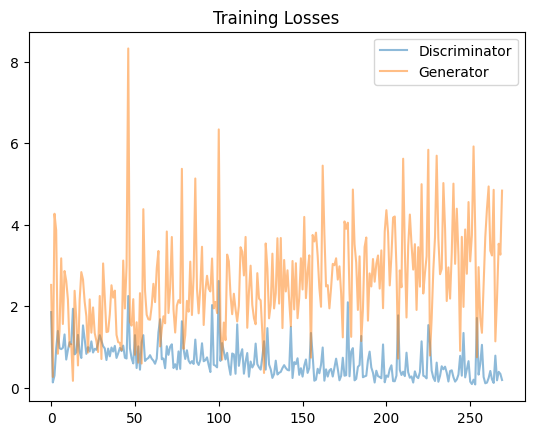

In [23]:
fig, ax = plt.subplots()
losses = np.array(losses)
plt.plot(losses.T[0], label='Discriminator', alpha=0.5)
plt.plot(losses.T[1], label='Generator', alpha=0.5)
plt.title("Training Losses")
plt.legend()

## Generator samples from training

View samples of images from the generator, and answer a question about the strengths and weaknesses of your trained models.

In [24]:
# helper function for viewing a list of passed in sample images
def view_samples(epoch, samples):
    fig, axes = plt.subplots(figsize=(16,4), nrows=2, ncols=8, sharey=True, sharex=True)
    for ax, img in zip(axes.flatten(), samples[epoch]):
        img = img.detach().cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        img = ((img + 1)*255 / (2)).astype(np.uint8)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        im = ax.imshow(img.reshape((32,32,3)))

In [25]:
# Load samples from generator, taken while training
with open('train_samples.pkl', 'rb') as f:
    samples = pkl.load(f)

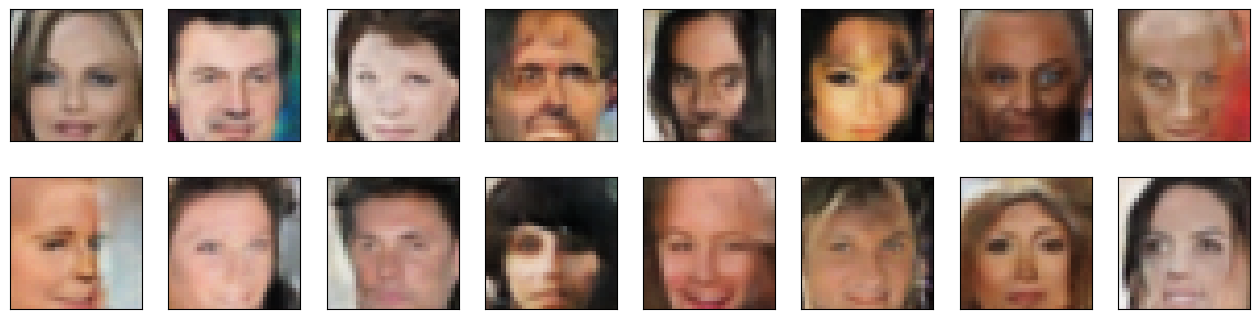

In [26]:
_ = view_samples(-1, samples)

### Question: What do you notice about your generated samples and how might you improve this model?
When you answer this question, consider the following factors:
* The dataset is biased; it is made of "celebrity" faces that are mostly white
* Model size; larger models have the opportunity to learn more features in a data feature space
* Optimization strategy; optimizers and number of epochs affect your final result


**Answer:** (Write your answer in this cell)
- The face generated at the bottom right has mismatch between the eyes whereas the bottom left is the combination between men and woman. Not sure if longer training or reducing latent vector can link together between both eyes and differentiate between woman and man faces.
- Running on 30 epochs, higher base of convolutional dimension of 128 generates better faces result as compared to lower 32-dimension.
- Using base of convolutional dimension of 128, 30 epochs shows better result as compared to any lower epochs.

### Submitting This Project
When submitting this project, make sure to run all the cells before saving the notebook. Save the notebook file as "dlnd_face_generation.ipynb" and save it as a HTML file under "File" -> "Download as". Include the "problem_unittests.py" files in your submission.